In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module ="openpyxl")

In [23]:
file_path = r"C:\Users\rajeshkumar.t\Desktop\ML\tranctions.csv"
df= pd.read_csv(file_path, low_memory =False)
print(df.columns)

Index(['transaction_yr', 'transaction_mth', 'transaction_wk', 'transaction_dt',
       'transaction_status', 'transaction_source', 'live_response_code',
       'payment_instrument', 'bank_code', 'hyp_flag', 'asp_flag',
       'merchant_id', 'merchant_status', 'marketplace_id', 'pg_id',
       'flipkart_emi_flag', 'marketplace_context', 'is_shopsy_order',
       'emi_flag', 'adonc_flag', 'count_of_tx', 'acct_cnt', 'tot_amt',
       'tot_eff_amt_paymnt'],
      dtype='object')


In [37]:
df_ts = df.groupby('transaction_dt').agg({
    'count_of_tx': 'sum',
    'tot_amt': 'sum',
    'acct_cnt': 'max'
}).reset_index()

df_ts['transaction_dt'] = pd.to_datetime(df_ts['transaction_dt'])
df_ts = df_ts.set_index('transaction_dt').sort_index()
df_ts = df_ts.iloc[:-1]
df_ts = df_ts.asfreq('D').ffill()

In [40]:
def create_multivariate_features(data):
    df= data.copy()
    
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    
    df['lag_1_tx'] = df['count_of_tx'].shift(1)
    df['lag_7_tx'] = df['count_of_tx'].shift(7)
    df['lag_1_amt'] = df['tot_amt'].shift(1)
    df['lag_1_user'] = df['acct_cnt'].shift(1)
    df['rolling_mean_3'] = df['count_of_tx'].shift(1).rolling(window=3).mean()
    return df

df_features = create_multivariate_features(df_ts).dropna()


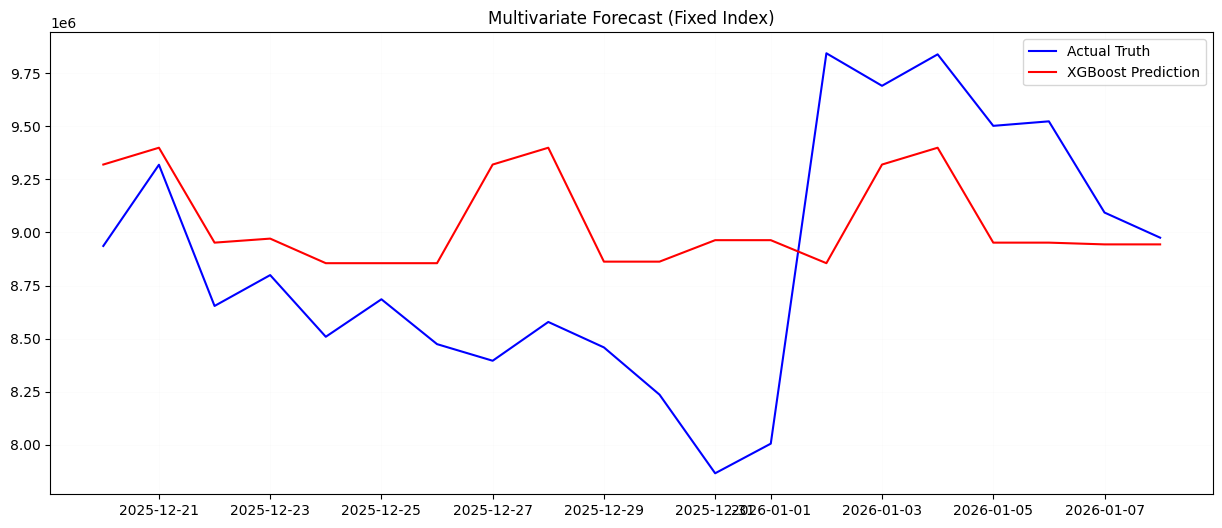

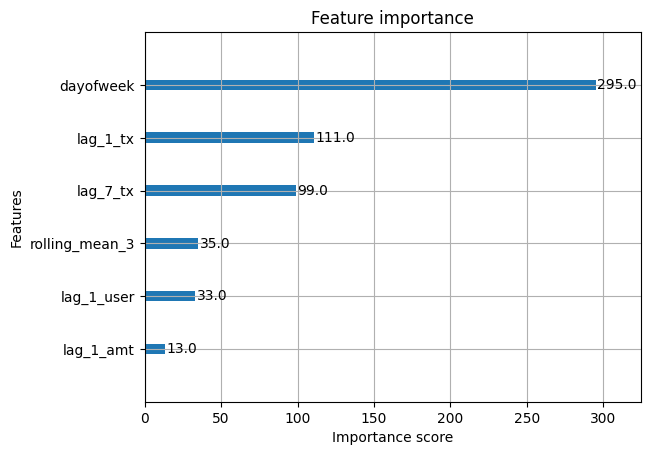

In [43]:
features = ['dayofweek', 'month', 'lag_1_tx',  'lag_7_tx', 'lag_1_amt','lag_1_user','rolling_mean_3']
target = 'count_of_tx'

train_size = int(len(df_features) * 0.9)
train= df_features.iloc[:-20].copy()
test = df_features.iloc[-20:].copy()

#train = df_features.iloc[:train_size].copy()
#test = df_features.iloc[train_size:].copy()

X_train, y_train = train[features], train[target]
X_test, y_test = test[features],test[target]

reg = xgb.XGBRegressor(n_estimators= 1000, 
                       learning_rate = 0.1,
                       max_depth=5,
                       early_stopping_rounds = 50)

reg.fit(X_train, y_train,
        eval_set=[(X_train,y_train), (X_test,y_test)],
        verbose=False)

test['prediction'] = reg.predict(X_test)

plt.figure(figsize=(15,6))
plt.plot(test.index, test[target], label='Actual Truth', color='blue')
plt.plot(test.index, test['prediction'], label= 'XGBoost Prediction', color ='red')
plt.title('Multivariate Forecast (Fixed Index)')
plt.legend()
plt.grid(True, alpha=0.03)
plt.show()

xgb.plot_importance(reg, max_num_features=10)
plt.show()